# Workshop-Paper Entity Re-run Analysis

Entity-collapse analysis for the workshop-paper entity re-run files. The data folder is **downloaded
from Google Drive** (`entity re-run for workshop paper-<timestamp>-3-001/`) into the repo root and is
**gitignored**; the timestamp changes per download, so cell 1 **auto-discovers the folder by regex** —
no path editing needed. Just drop the unzipped folder in the repo root and run all cells.

**Provenance.** These `*.entities_by_round.jsonl` files were produced by
`collapse-randomness-research/.../tag_entities_workshop_paper.py` from the **raw generations** in
`all_experiments/graphite/baseline/<regime>/experiment_outputs/...` — entities tagged per answer with
OpenAI `gpt-5.4-mini` (balanced prompt) and canonicalized with `gpt-5.2` embeddings. (This is a
*different* artifact from the repo's aggregate `entity_extraction_output/<org>/<model>/local_<variant>_entity_results.json`
used by `visualization.ipynb` / `agentic-rag-visualization.ipynb`.) Mistral files come from the
`paraphrase_on` condition but are labeled plainly as "Mistral-7B".

Covered: 4 models (Qwen2.5-14B, Llama-3.1-8B, Mistral-7B, DeepSeek-R1-Distill-7B) x 3 regimes
(Replace All / Replace One / Search). Metrics (recomputed to match `entity_extraction.py`):

- **Unique Entities Per Round** - union of mapped entities across the 10 runs in a round, averaged across questions.
- **Entity Similarity Per Round** - mean pairwise cosine similarity of binary entity-mention vectors across the 10 runs, averaged across questions (empty-entity answers contribute 0.0).

Each model gets a baseline comparison (Replace All / One / Search overlaid). Images are saved to
`workshop_entity_visualizations/`.

In [1]:
import os, re, json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# -- Locate the entity re-run folder (downloaded from Google Drive) --
# Its name carries a Drive export timestamp that changes each download, so discover it by REGEX
# instead of hardcoding. There should be exactly one such folder in the repo root.
_PAT = re.compile(r"entity re-run for workshop paper-.*")
_outer = sorted(d for d in os.listdir(".") if _PAT.fullmatch(d) and os.path.isdir(d))
if not _outer:
    raise FileNotFoundError(
        "No 'entity re-run for workshop paper-*' folder in the repo root. "
        "Download it from Google Drive and unzip it here (the folder is gitignored).")
_OUTER = _outer[-1]                       # newest if several
_inner = [d for d in os.listdir(_OUTER) if os.path.isdir(os.path.join(_OUTER, d))]
BASE = os.path.join(_OUTER, _inner[0]) if _inner else _OUTER
print("Using entity re-run folder:", BASE)

OUT_DIR = "workshop_entity_visualizations"
os.makedirs(OUT_DIR, exist_ok=True)

REGIME_COLOR = {"Replace All": "#1f77b4", "Replace One": "#ff7f0e", "Search": "#2ca02c"}
SEP = "\u00b7"  # middle-dot separator used in plot labels

# (display model name, org_model filename token, optional extra filename token)
_MODELS = [
    ("Qwen2.5-14B", "Qwen_Qwen2.5-14B-Instruct", ""),
    ("Llama-3.1-8B", "meta-llama_Llama-3.1-8B-Instruct", ""),
    ("Mistral-7B", "mistralai_Mistral-7B-Instruct-v0.3", "paraphrase_on_"),
    ("DeepSeek-R1-Distill-7B", "deepseek-ai_DeepSeek-R1-Distill-Qwen-7B", ""),
]
_REGIMES = [("Replace All", "replace_all"), ("Replace One", "replace_one"), ("Search", "search")]
_SLUG = {"Qwen2.5-14B": "qwen", "Llama-3.1-8B": "llama", "Mistral-7B": "mistral",
         "DeepSeek-R1-Distill-7B": "deepseek"}

def lbls(disp):
    """The 3 regime labels for a model, in Replace All / Replace One / Search order."""
    return [f"{disp} {SEP} {rlabel}" for rlabel, _ in _REGIMES]

# Build the file table: label -> {path, color, slug, model, regime}.
FILES = {}
for disp, mtok, extra in _MODELS:
    for rlabel, rtok in _REGIMES:
        label = f"{disp} {SEP} {rlabel}"
        fname = (f"model_collapse_log_graphite_baseline_{rtok}_{mtok}_{extra}"
                 f"local_{rtok}.entities_by_round.jsonl")
        FILES[label] = {
            "path": f"{BASE}/{fname}",
            "color": REGIME_COLOR[rlabel],
            "slug": f"{_SLUG[disp]}_{rtok}",
            "model": disp,
            "regime": rlabel,
        }


# -- Helpers (replicate entity_extraction.py metric definitions) --

def compute_entity_similarity(entity_vectors):
    """Mean pairwise cosine similarity of binary entity-mention vectors.
    A pair where either vector has zero norm (empty-entity answer) contributes 0.0."""
    n = len(entity_vectors)
    if n < 2:
        return 0.0
    sims = []
    for i in range(n):
        for j in range(i + 1, n):
            a, b = entity_vectors[i], entity_vectors[j]
            n1 = np.linalg.norm(a)
            n2 = np.linalg.norm(b)
            sim = float(np.dot(a, b) / (n1 * n2)) if n1 > 0 and n2 > 0 else 0.0
            sims.append(sim)
    return float(np.mean(sims))


def analyze_file(path):
    """Per-round mean unique-entity count and mean entity similarity across all questions."""
    per_round_unique = defaultdict(list)
    per_round_sim = defaultdict(list)
    max_rounds = 0
    with open(path, "r", encoding="utf-8") as fh:
        for line in fh:
            rec = json.loads(line)
            rounds = rec["round_numbers"]
            counts = rec["entity_counts"]
            mapped = rec["mapped_entities"]
            max_rounds = max(max_rounds, len(rounds))
            for idx in range(len(rounds)):
                per_round_unique[idx].append(len(counts[idx]))
                runs = mapped[idx]
                vocab = sorted({e for run in runs for e in run})
                vi = {e: i for i, e in enumerate(vocab)}
                vectors = []
                for run in runs:
                    v = np.zeros(len(vocab))
                    for e in run:
                        v[vi[e]] = 1.0
                    vectors.append(v)
                per_round_sim[idx].append(compute_entity_similarity(vectors))
    mean_unique = [float(np.mean(per_round_unique[i])) for i in range(max_rounds)]
    mean_sim = [float(np.mean(per_round_sim[i])) for i in range(max_rounds)]
    return mean_unique, mean_sim


def plot_comparison(labels, metric_key, ylabel, title, save_path):
    fig, ax = plt.subplots(figsize=(10, 6))
    for label in labels:
        vals = results[label][metric_key]
        ax.plot(range(1, len(vals) + 1), vals, linewidth=2.5,
                label=FILES[label]["regime"], color=FILES[label]["color"])
    ax.set_xlabel("Round", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# Compute everything up front so the plotting cells just render.
results = {}
for label, info in FILES.items():
    mu, ms = analyze_file(info["path"])
    results[label] = {"unique": mu, "similarity": ms}
    print(f"{label}: {len(mu)} rounds")


Using entity re-run folder: entity re-run for workshop paper-20260624T211528Z-3-001\entity re-run for workshop paper


Qwen2.5-14B · Replace All: 10 rounds


Qwen2.5-14B · Replace One: 20 rounds


Qwen2.5-14B · Search: 30 rounds


Llama-3.1-8B · Replace All: 10 rounds


...

Mistral-7B · Replace One: 20 rounds


Mistral-7B · Search: 30 rounds


DeepSeek-R1-Distill-7B · Replace All: 10 rounds


DeepSeek-R1-Distill-7B · Replace One: 20 rounds


DeepSeek-R1-Distill-7B · Search: 30 rounds


## Qwen2.5-14B baseline comparison

The three update regimes overlaid (Replace All / Replace One / Search). Note the differing round counts (10 / 20 / 30).

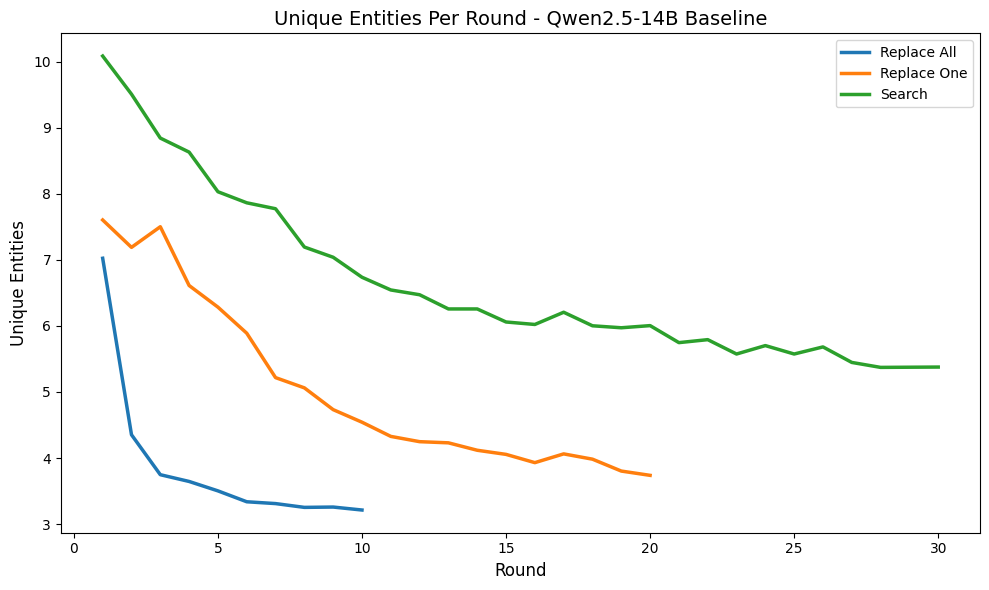

In [2]:
plot_comparison(lbls("Qwen2.5-14B"), "unique", "Unique Entities",
                "Unique Entities Per Round - Qwen2.5-14B Baseline",
                f"{OUT_DIR}/qwen_baseline_unique_entities_per_round.png")

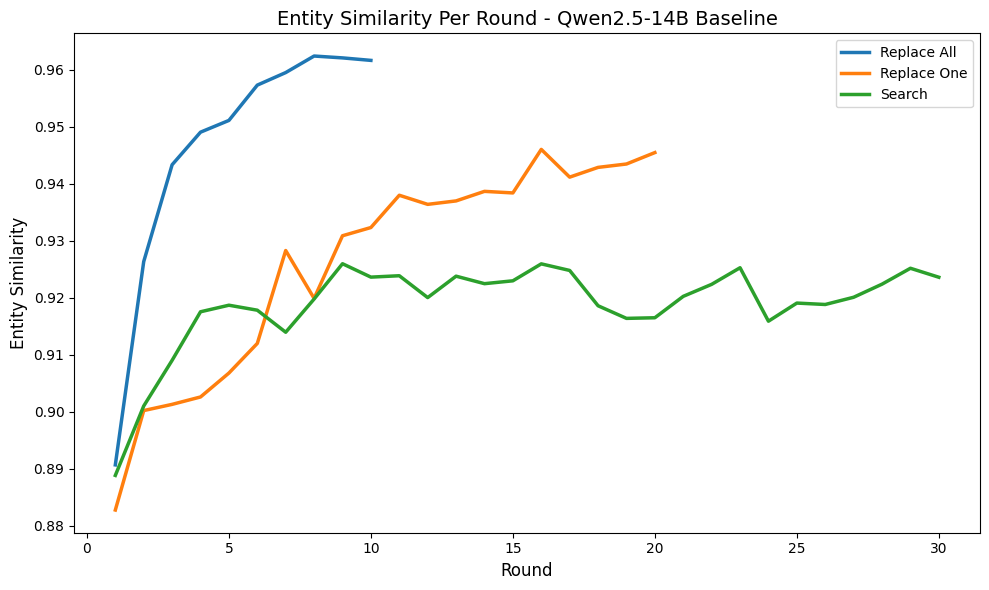

In [3]:
plot_comparison(lbls("Qwen2.5-14B"), "similarity", "Entity Similarity",
                "Entity Similarity Per Round - Qwen2.5-14B Baseline",
                f"{OUT_DIR}/qwen_baseline_entity_similarity_per_round.png")

## Llama-3.1-8B baseline comparison

The three update regimes overlaid (Replace All / Replace One / Search). Note the differing round counts (10 / 20 / 30).

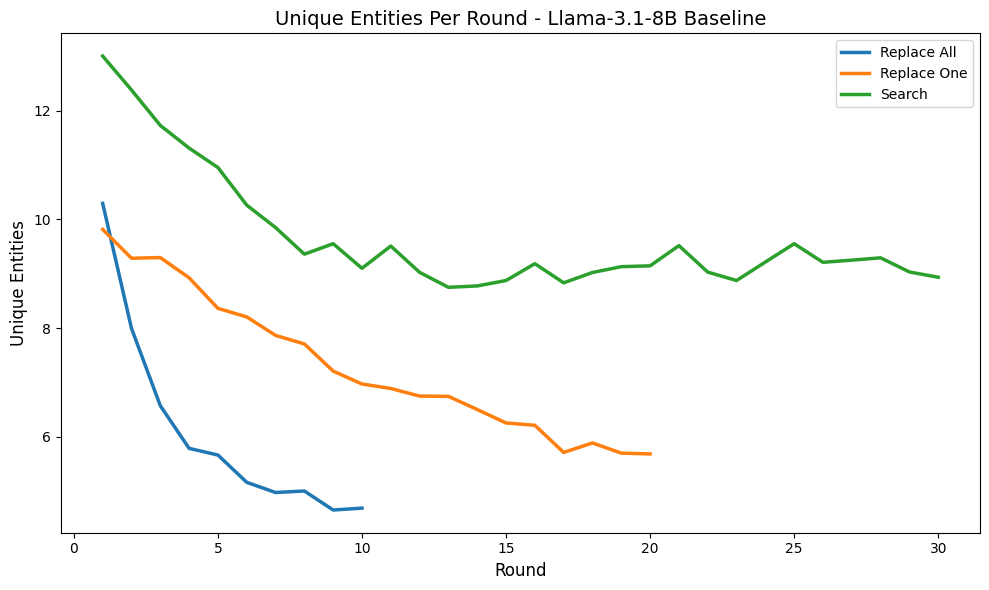

In [4]:
plot_comparison(lbls("Llama-3.1-8B"), "unique", "Unique Entities",
                "Unique Entities Per Round - Llama-3.1-8B Baseline",
                f"{OUT_DIR}/llama_baseline_unique_entities_per_round.png")

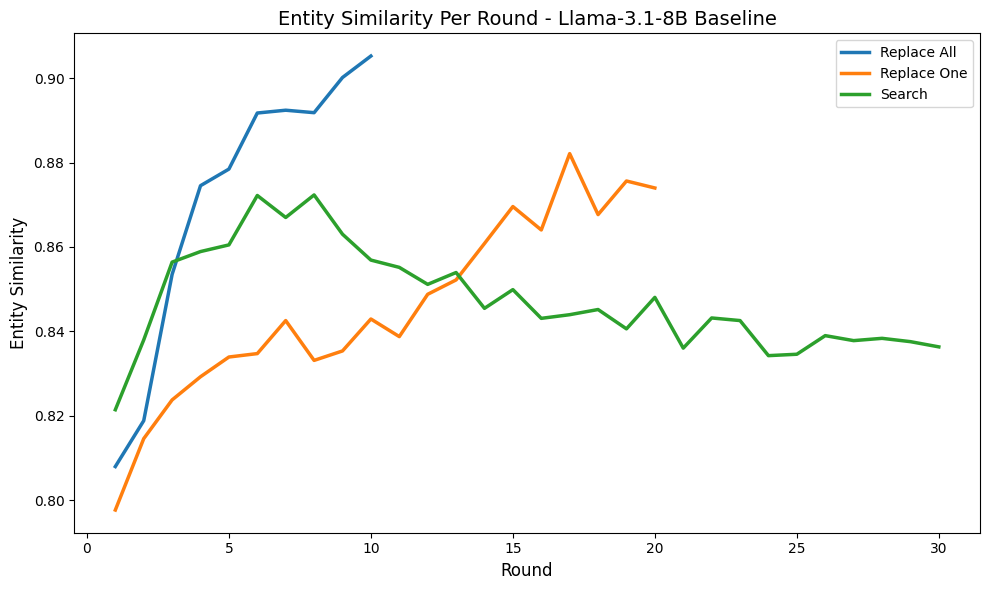

In [5]:
plot_comparison(lbls("Llama-3.1-8B"), "similarity", "Entity Similarity",
                "Entity Similarity Per Round - Llama-3.1-8B Baseline",
                f"{OUT_DIR}/llama_baseline_entity_similarity_per_round.png")

## Mistral-7B baseline comparison

The three update regimes overlaid (Replace All / Replace One / Search). Note the differing round counts (10 / 20 / 30).

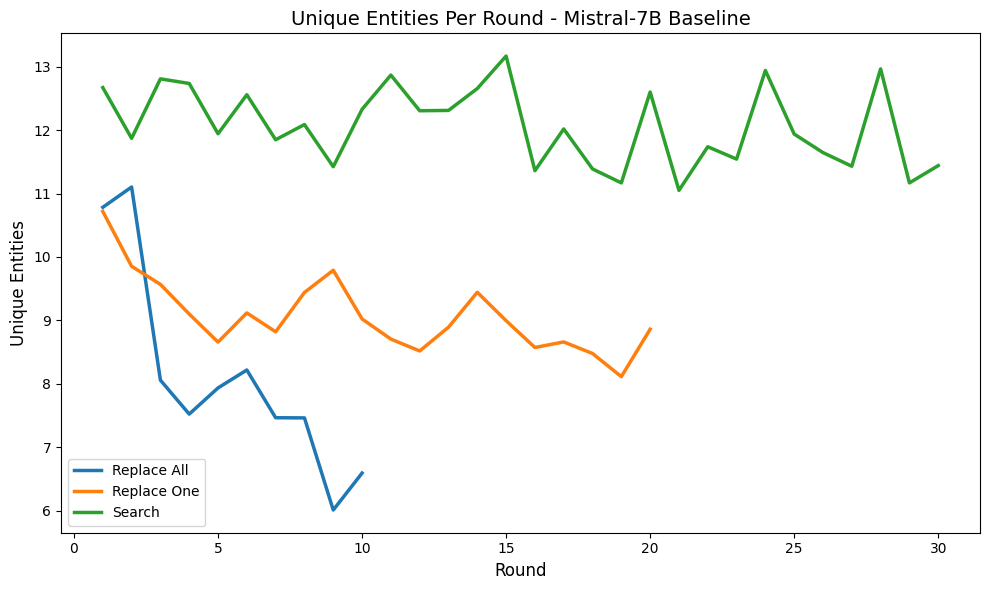

In [6]:
plot_comparison(lbls("Mistral-7B"), "unique", "Unique Entities",
                "Unique Entities Per Round - Mistral-7B Baseline",
                f"{OUT_DIR}/mistral_baseline_unique_entities_per_round.png")

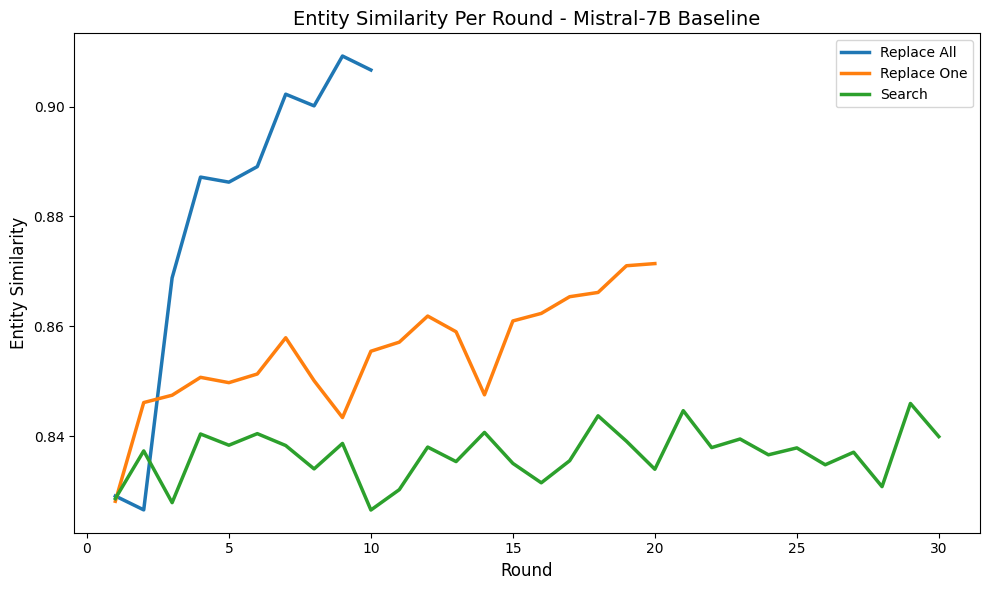

In [7]:
plot_comparison(lbls("Mistral-7B"), "similarity", "Entity Similarity",
                "Entity Similarity Per Round - Mistral-7B Baseline",
                f"{OUT_DIR}/mistral_baseline_entity_similarity_per_round.png")

## DeepSeek-R1-Distill-7B baseline comparison

The three update regimes overlaid (Replace All / Replace One / Search). Note the differing round counts (10 / 20 / 30).

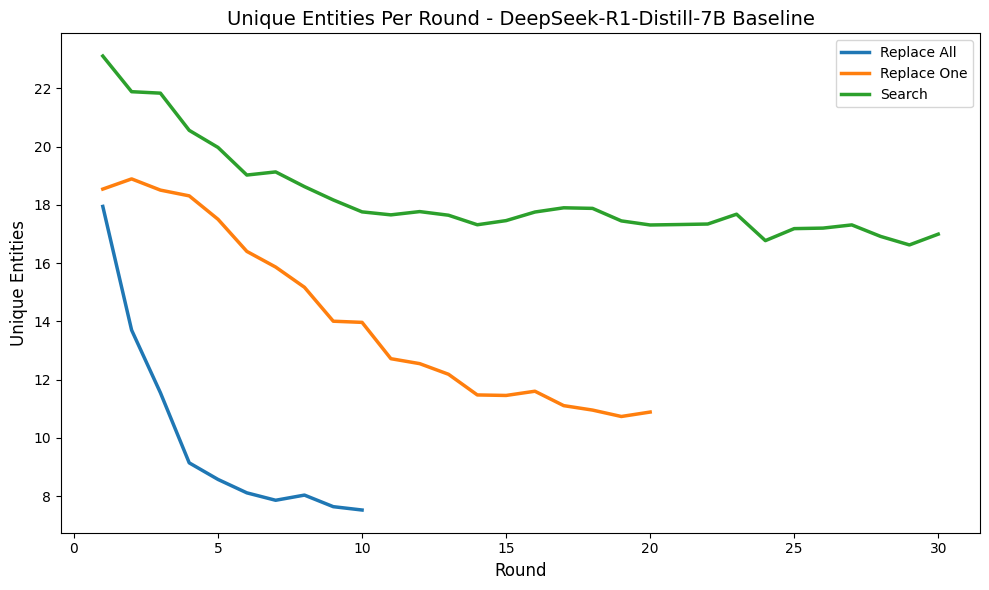

In [8]:
plot_comparison(lbls("DeepSeek-R1-Distill-7B"), "unique", "Unique Entities",
                "Unique Entities Per Round - DeepSeek-R1-Distill-7B Baseline",
                f"{OUT_DIR}/deepseek_baseline_unique_entities_per_round.png")

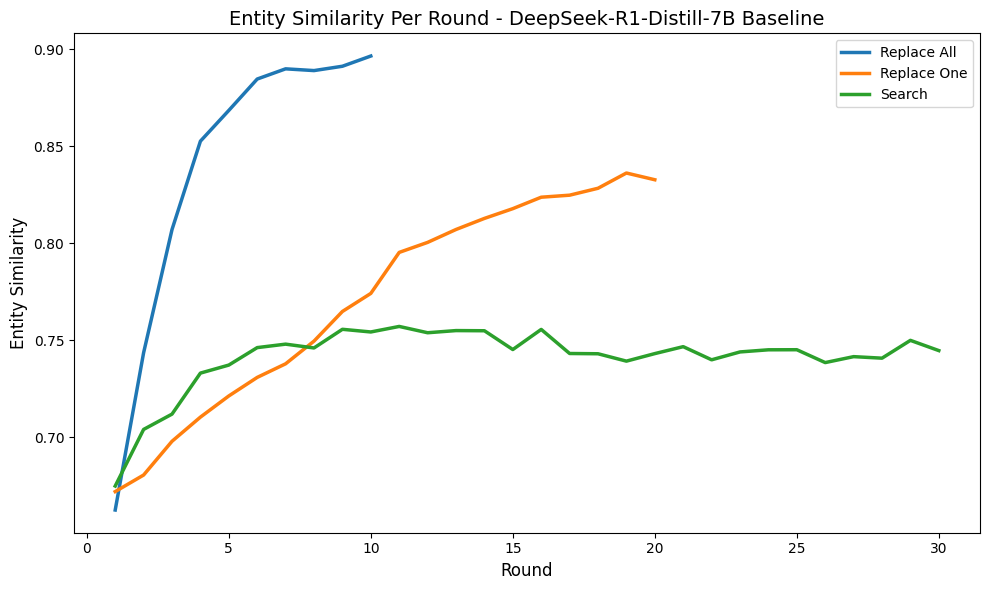

In [9]:
plot_comparison(lbls("DeepSeek-R1-Distill-7B"), "similarity", "Entity Similarity",
                "Entity Similarity Per Round - DeepSeek-R1-Distill-7B Baseline",
                f"{OUT_DIR}/deepseek_baseline_entity_similarity_per_round.png")